# Conversation (part of it) Affective State | Affective Analysis

What we gonna do is write a functionality that from a part of a conversation extracts the affective state of the participants. 

> **Note** 
> Most of the smart talk in this notebook is AI generated.

-----
## Introduction:

To build a meaningful radar chart for conversational affective analysis, we need labels that capture the interpersonal dynamics of the chat, not just internal feelings.

If we use standard "inner" emotions (like Sadness or Fear), the radar chart often looks flat because people rarely express those purely in a professional or casual text chat. Instead, I propose a set of **Interpersonal Affective States** that focus on the energy and intent of the participants.

Here are 8 proposed labels designed to create a balanced, insightful radar chart:

1. The Proactive Quad (Active/Constructive)
Engagement: The level of active participation and focus on the topic. High scores mean the user is "leaning in."

Affability: The warmth, friendliness, and politeness of the tone. This measures the "social glue."

Confidence: The degree of certainty, assertiveness, and authority in the language used.

Curiosity: Interest in the other person's perspective (asking questions, seeking clarification).

2. The Reactive Quad (Passive/Defensive)
Skepticism: Doubt, hesitation, or critical questioning. High scores indicate a "trust-but-verify" or oppositional stance.

Agitation: Subtle signs of frustration, impatience, or annoyance (short sentences, sharp punctuation).

Defensiveness: Protecting one's position or deflecting. This often appears when a user feels criticized.

Detachment: A lack of emotional investment or "robotic" responses. This helps identify if a participant is checking out.

### Why these 8?
A radar chart works best when opposing axes represent contrasting states. For example:

Affability vs. Agitation (The "Vibe" axis)

Engagement vs. Detachment (The "Presence" axis)

Confidence vs. Curiosity (The "Information Flow" axis)

Skepticism vs. Defensiveness (The "Resistance" axis)

How it would look in practice
Imagine a conversation between a Manager and an Employee during a performance review:

The Manager might show high Confidence and Affability, but low Curiosity.

The Employee might show high Engagement and Defensiveness, with rising Agitation.

The resulting radar shapes would immediately visualize the power dynamic and the "temperature" of the room.


In [1]:
from typing import Iterable


def sort_dict_by_keys(d: dict[str, any], keys_order: Iterable[str]) -> dict[str, any]:
    return {k: d[k] for k in keys_order if k in d}

In [2]:
labels_order: Iterable[str] = tuple(
    [
        "Engagement",
        "Affability",
        "Confidence",
        "Skepticism",
        # ordered so opposites are across from each other in the polar chart
        "Detachment",
        "Agitation",
        "Curiosity",
        "Defensiveness",
    ]
)

labels_description = sort_dict_by_keys(
    {
        "Engagement": 'The level of active participation and focus on the topic. High scores mean the user is "leaning in."',
        "Affability": 'The warmth, friendliness, and politeness of the tone. This measures the "social glue."',
        "Confidence": "The degree of certainty, assertiveness, and authority in the language used.",
        "Curiosity": "Interest in the other person's perspective (asking questions, seeking clarification).",
        "Skepticism": 'Doubt, hesitation, or critical questioning. High scores indicate a "trust-but-verify" or oppositional stance.',
        "Agitation": "Subtle signs of frustration, impatience, or annoyance (short sentences, sharp punctuation).",
        "Defensiveness": "Protecting one's position or deflecting. This often appears when a user feels criticized.",
        "Detachment": 'A lack of emotional investment or "robotic" responses. This helps identify if a participant is checking out.',
    },
    labels_order,
)
labels_color = sort_dict_by_keys(
    {
        "Engagement": "#E751CC",
        "Affability": "#F4A261",
        "Confidence": "#03F0D4",
        "Curiosity": "#3CDB59",
        "Skepticism": "#D62828",
        "Agitation": "#F7F300",
        "Defensiveness": "#7B4DBA",
        "Detachment": "#2C74F0",
    },
    labels_order,
)


assert len(labels_color) == len(labels_description)

**Implementation Tip:** The "Chain of Thought" PromptTo get the most accurate values from the AI, don't just ask for the numbers.

Use a prompt structure like this:

"""

Analyze the conversation for the following 8 affective states. For each state:
- Briefly quote the evidence from the text.
- Reason why this indicates a specific level of intensity.
- Provide the final value on a scale of 0.0 to 1.0.

"""

"This "reasoning" step prevents the model from hallucinating random numbers and ensures the $0.8$ for Agitation is actually backed by the text.

In [3]:
## example of the output:

# For an AI model to analyze affective states effectively, the most efficient scale is 0.0 to 1.0 (float/decimal). (sad another ai).

example_output = sort_dict_by_keys(
    {
        "Engagement": 0.8,
        "Affability": 0.6,
        "Confidence": 0.7,
        "Curiosity": 0.3,
        "Skepticism": 0.2,
        "Agitation": 0.4,
        "Defensiveness": 0.5,
        "Detachment": 0.1,
    },
    labels_order,
)

In [4]:
from matplotlib.projections import get_projection_names
get_projection_names()

['3d', 'aitoff', 'hammer', 'lambert', 'mollweide', 'polar', 'rectilinear']

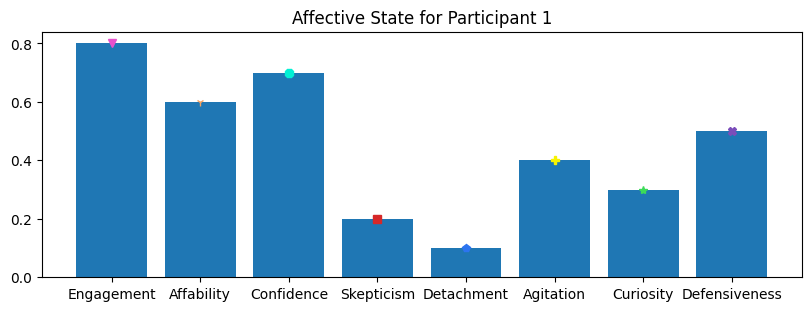

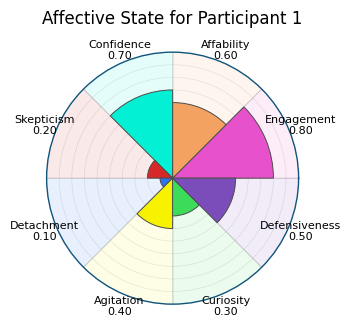

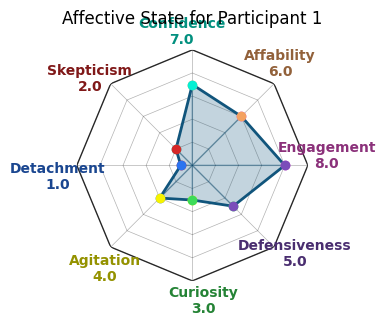

In [5]:
import importlib
import plotting.plotting as pl
importlib.reload(pl)

pl.render_charts(
    indicator_name="Participant 1",
    data=example_output,
    colors=labels_color,
    height_px=300,
)

## Real-ish Example

source [conversation1](https://www.quora.com/How-is-a-conversation-between-an-employee-and-an-angry-boss-The-employee-is-a-fresher-The-fresher-completed-his-work-but-his-senior-didn-t-What-is-the-conversation-like)

In [6]:
conversation1 = """
Boss: Why wasn’t the client deliverable sent this morning? We had a hard deadline at 10:00. Explain.

Jonny: I completed my portion of the work and uploaded the files to the shared folder by 7:30. I also updated the task status and added implementation notes in the doc.

Boss: The client received an incomplete package. Your senior was responsible for integration and sign-off. Why did you assume they’d finish it on time?

Jonny: I saw the senior marked the integration task as “in progress” yesterday and asked if they needed help. They said they had it under control and would finish by 9:30. I didn’t want to overstep, so I focused on finishing my assigned module and prepared the supporting documentation.

Boss: That’s not sufficient. When a dependent task has a hard deadline, you escalate if the owner is behind. Did you notify me or send a reminder before the deadline?

Jonny: I didn’t escalate to you. I sent a message in the team channel at 8:45 asking for a quick confirmation; there was no response. I interpreted the silence as them proceeding. I should have followed up more assertively.

Boss: The client impact is serious. You’re new, but responsibility includes ensuring handoffs complete. Moving forward, this is what I expect:

For interdependent deliverables, confirm readiness at least one hour before the deadline.
If the owner is unresponsive or indicates delay, notify me immediately.
When you finish your part, create a checklist item for the next owner and copy me on the final “ready to send” message.
Jonny: Understood. I’ll adopt those steps and will copy you on final confirmations going forward. If it helps, I can draft the checklist template and a short escalation message for the team.

Boss: Do that by end of day. Also, reach out to the senior and get a postmortem: what blocked them and how we prevent recurrence. I’ll decide on the client communication after I review their response.

Jonny: I’ll contact the senior now, request their status and blockers, and send you a summary within the hour. I’ll prepare the checklist template and the proposed escalation message as well.

Boss: Good. Learn from this and treat deadlines as shared responsibilities.
"""

In [7]:
def get_system_prompt_for_affective_analysis(labels_description: dict[str, str]) -> str:
    return f"""You

---------

LABELS:
{chr(10).join([f"- {k}: {v}" for k, v in labels_description.items()])}

### Why these {len(labels_description)}?
A radar chart works best when opposing axes represent contrasting states. For example:

Affability vs. Agitation (The "Vibe" axis)

Engagement vs. Detachment (The "Presence" axis)

Confidence vs. Curiosity (The "Information Flow" axis)

Skepticism vs. Defensiveness (The "Resistance" axis)

How it would look in practice
Imagine a conversation between a Manager and an Employee during a performance review:

The Manager might show high Confidence and Affability, but low Curiosity.

The Employee might show high Engagement and Defensiveness, with rising Agitation.

The resulting radar shapes would immediately visualize the power dynamic and the "temperature" of the room.

---------

Analyze the conversation for the following {len(labels_description)} affective states. For each state:
- Briefly quote the evidence from the text.
- Reason why this indicates a specific level of intensity.
- Provide the final value on a scale of 0.0 to 1.0.
- All and every label must be addressed in the output, even if the score is 0.0 (indicating no presence of that affective state).

OUTPUT FORMAT:
- Affability: <score>, <reasoning + optional evidence>
- Engagement: <score>, <reasoning + optional evidence>
- Confidence: <score>, <reasoning + optional evidence>
- Curiosity: <score>, <reasoning + optional evidence>
- Skepticism: <score>, <reasoning + optional evidence>
- Agitation: <score>, <reasoning + optional evidence>
- Defensiveness: <score>, <reasoning + optional evidence>
- Detachment: <score>, <reasoning + optional evidence>

Example Output for (Boss, employee conversation):
- Affability: 0.6, The boss uses polite language and offers constructive feedback, "...please consider..."
- Engagement: 0.8, The boss responds promptly and provides detailed explanations, "...let me elaborate..."
...
- Detachment: 0.1, The boss is emotionally invested and responsive to the employee's concerns.
"""

def get_user_prompt_for_affective_analysis(conversation: str, participant_name: str) -> str:
    return f"""In the given conversation, analyze the affective states of the participant {participant_name}.

    CONVERSATION:
{conversation}
"""

In [8]:
import os
from dotenv import load_dotenv
from openai import OpenAI
from huggingface_hub import login
from transformers import AutoTokenizer, AutoModelForTokenClassification
from transformers import pipeline
from IPython.display import Markdown, display
from time import monotonic

In [9]:
load_dotenv(override=True)

openai= OpenAI()
ollama = OpenAI(base_url="http://localhost:11434/v1")

hg_api_key = os.getenv("HF_TOKEN")
login(token=hg_api_key)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


>**Note**
>
> To extract the participants from the example conversation, simple regex would be more appropriate than what we are doing here, but that's not the point of this notebook. Also, in less structured conversations, an LLM would be a better choice to identify participants.

In [10]:
# chunking into sentences of lines didn't work well, the model performance was worse than on the full text.

# def chunk_conversation(conversation: str, chunk_sep=".") -> list[str]:
#     conversation_chunks = [c for c in conversation.split(chunk_sep)]
#     for chunk_idx, chunk in enumerate(conversation_chunks):
#         if len(chunk.strip()) > 512:
#             chunk_words = chunk.split(" ")
#             i = 0
#             words_in_chunk = len(chunk_words)
#             num_parts = (
#                 words_in_chunk + 9
#             ) // 10  # Calculate the number of parts needed
#             for _ in range(num_parts):
#                 current_part = " ".join(chunk_words[i : min(i + 10, words_in_chunk)])[
#                     :512
#                 ]

#                 # if this is the first part, replace the original chunk, otherwise insert it as a new chunk at the end of the list
#                 if i == 0:
#                     conversation_chunks[chunk_idx] = current_part
#                 else:
#                     conversation_chunks.append(current_part)
#                 i += 10

#     return conversation_chunks


def normalize_name(name: str) -> str:
    return name.strip().replace("\n", "").replace("\r", "").replace("\t", "").lower()


def extract_participants(conversation: str) -> list[str]:

    model_name = "Jean-Baptiste/roberta-large-ner-english"

    start_time = monotonic()

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForTokenClassification.from_pretrained(model_name)
    toks = tokenizer(conversation, add_special_tokens=False)

    # the model accepts max 512 tokens, it might add special tokes at the beginning and end
    chunk_size = 512 - 2
    conversation_chunks = []
    for i in range(0, len(toks.input_ids), chunk_size):
        chunk_ids = toks.input_ids[i : i + chunk_size]
        conversation_chunks.append(tokenizer.decode(chunk_ids))

    print("no of chunks: ", len(conversation_chunks))

    pipe = pipeline(
        "ner",
        model=model,
        tokenizer=tokenizer,
        aggregation_strategy="simple",
    )

    not_participant_words = {"her", "his", "their", "my", "your", "our"}

    participants = set()

    # for c in chunk_conversation(conversation1):
    for c in conversation_chunks:
        ner_results = pipe(c)

        # print("🪓Chunk: ", c)
        print("NER Results:\n")
        for r in ner_results:
            print(
                f"{ r.get('word').replace("\n", "\\n")} ({r.get('entity_group')}, {r.get('score'):.2f})"
            )

        participants.update(
            normalize_name(r.get("word"))
            for r in ner_results
            if r.get("entity_group") == "PER"
            and r.get("score") > 0.4
            and normalize_name(r.get("word")) not in not_participant_words
        )

    end_time = monotonic()
    print(f"NER execution time: {end_time - start_time:.4f} ")

    return participants


participants = extract_participants(conversation1)
print("Participants: ", participants)

# would be better to keep the original casing of the names, or at least capitalize them. The normalization was done to deduplicate different mentions of the same participant, but it might hurt performance of the affective analysis model.

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

RobertaForTokenClassification LOAD REPORT from: Jean-Baptiste/roberta-large-ner-english
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Token indices sequence length is longer than the specified maximum sequence length for this model (515 > 512). Running this sequence through the model will result in indexing errors


no of chunks:  2
NER Results:

\nBoss (PER, 0.66)
\nJonny (PER, 0.85)
\nBoss (PER, 0.64)
\nJonny (PER, 0.83)
\nBoss (PER, 0.65)
\nJonny (PER, 0.83)
\nBoss (PER, 0.64)
Jonny (PER, 0.98)
\nBoss (PER, 0.63)
\nJonny (PER, 0.85)
\nBoss (PER, 0.64)
NER Results:

NER execution time: 4.0780 
Participants:  {'jonny', 'boss'}


In [11]:
def generate_affective_analysis(conversation: str, participants: list[str]):
    analysis_results_texts = {}
    for participant in participants:
        response = ollama.chat.completions.create(
            # model="llama3.2",
            model="llama3.1:8b",
            messages=[
                {
                    "role": "system",
                    "content": get_system_prompt_for_affective_analysis(
                        labels_description
                    ),
                },
                {
                    "role": "user",
                    "content": get_user_prompt_for_affective_analysis(
                        conversation, participant
                    ),
                },
            ],
        )

        content = response.choices[0].message.content
        analysis_results_texts[participant] = content
    return analysis_results_texts


analysis_results_texts = generate_affective_analysis(conversation1, participants)

# display(Markdown(content))
print(analysis_results_texts)

{'jonny': 'Here\'s the analysis of Jonny\'s affective states during the conversation:\n\n- Affability: 0.7, Jonny uses polite language throughout the conversation (e.g., "I didn\'t want to overstep") and shows a willingness to learn from his mistakes ("If it helps, I can draft the checklist template..."), displaying a friendly tone.\n  \n- Engagement: 0.9, Jonny responds promptly to each of the boss\'s questions and elaborates on his actions ("I sent a message in the team channel at 8:45 asking for a quick confirmation"; "I should have followed up more assertively"). He shows active participation and focus on understanding the issues.\n\n- Confidence: 0.5, Jonny seems cautious when discussing what to do differently in the future. At times, his responses contain phrases like "I didn\'t want to overstep," which can suggest a lack of confidence about his own decision-making authority.\n\n- Curiosity: 0.3, While Jonny asks for clarification on some points (e.g., "If it helps"), he does not

In [12]:
import re

def parse_affective_analysis(text: str, labels: list[str]) -> dict[str, float]:
    """
    Parse the affective analysis response and extract scores for each label.
    Uses labels_order to guide extraction - searches for each label specifically.
    Expected format: "- Label: score, explanation"
    """
    result = {}
    missing_labels = []

    text = text.replace("*", "").replace("#", "")
    
    for label in labels:
        # Search for pattern specific to this label: "- Label: score"
        pattern = rf'-*\s*{re.escape(label)}:\s*([\d.]+)'
        match = re.search(pattern, text)
        
        if match:
            try:
                result[label] = float(match.group(1))
            except ValueError:
                missing_labels.append(label)
        else:
            missing_labels.append(label)
    
    return result, missing_labels

parsed_scores_per_participant = {}
# Parse the LLM response
for participant, content in analysis_results_texts.items():
    parsed_scores, missing = parse_affective_analysis(content, labels_order)
    parsed_scores_per_participant[participant] = parsed_scores
    print(f"🦆 Participant: {participant}")
    print(f"Parsed scores: {parsed_scores}")
    print(f"Missing labels: {missing}")

🦆 Participant: jonny
Parsed scores: {'Engagement': 0.9, 'Affability': 0.7, 'Confidence': 0.5, 'Skepticism': 0.1, 'Detachment': 0.1, 'Agitation': 0.2, 'Curiosity': 0.3, 'Defensiveness': 0.4}
Missing labels: []
🦆 Participant: boss
Parsed scores: {'Engagement': 0.9, 'Affability': 0.7, 'Confidence': 0.8, 'Skepticism': 0.3, 'Detachment': 0.0, 'Agitation': 0.6, 'Curiosity': 0.2, 'Defensiveness': 0.2}
Missing labels: []



📊 Rendering chart(s) for participant: jonny


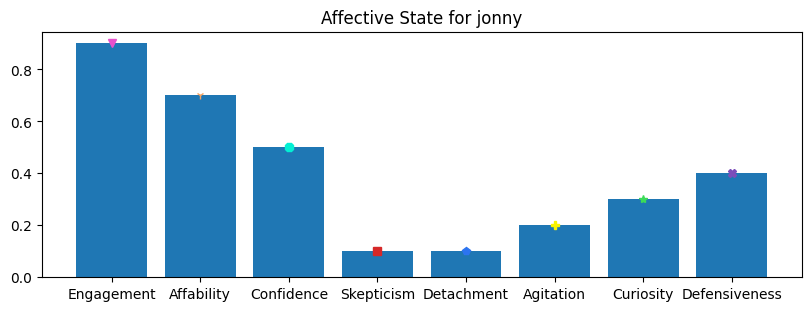

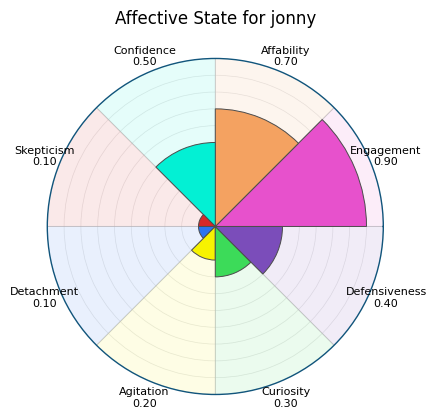

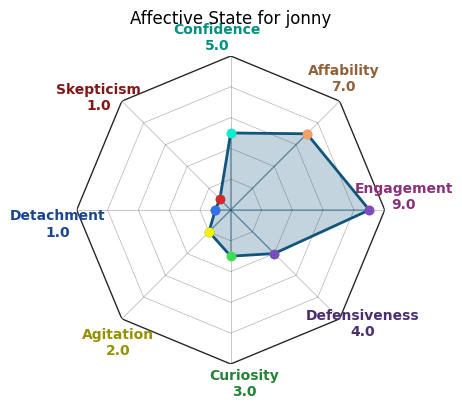


📊 Rendering chart(s) for participant: boss


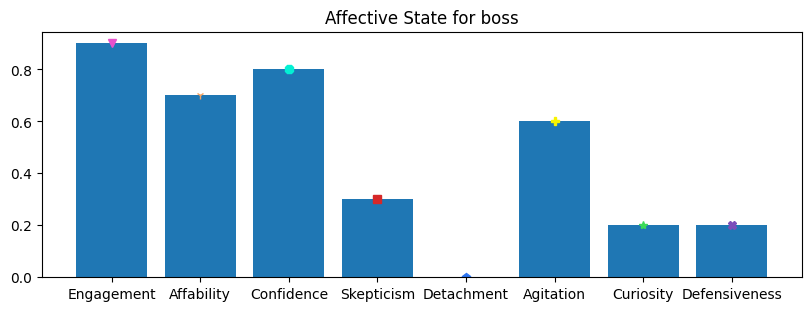

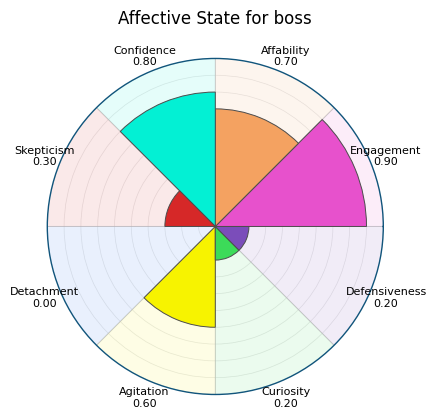

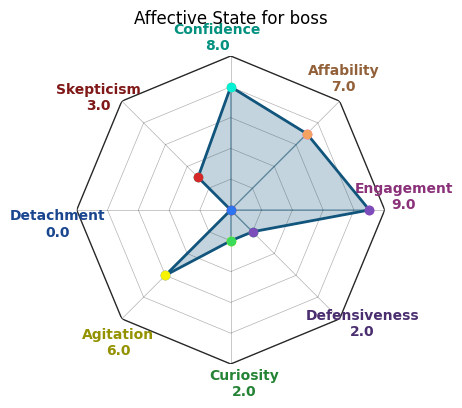

In [13]:
import importlib
import plotting.plotting as pl

importlib.reload(pl)


for participant, parsed_scores in parsed_scores_per_participant.items():
    print()
    print(f"📊 Rendering chart(s) for participant: {participant}")
    pl.render_charts(
        indicator_name=participant,
        data=sort_dict_by_keys(parsed_scores, labels_order),
        colors=labels_color,
        height_px=400,
    )

# all charts shows the same data

## Future Directions

Future iterations could slice a long conversation into segments (e.g., 1-minute windows) to track how these affective states evolve over time, creating an animated radar chart that shows the "emotional arc" of the interaction, or something like that.

Slightly more advanced option is to use a rolling window of the last N messages to capture the most recent affective state, which is often more relevant for real-time applications, which could be integrated into a live chat interface to provide ongoing feedback on the emotional tone of the conversation or a more challenging one would be to integrate it into a video call analysis tool that processes both audio and text to provide a comprehensive affective profile of the participants in real time.

Additionally, after the conversation is analyzed, we could use the extracted affective states to generate personalized recommendations for improving communication, such as suggesting more empathetic language when Agitation is high or encouraging more open-ended questions when Curiosity is low.
